## Simran Amesar

## Matriculation number - 100007050

In [577]:
texts = [
    # Positive
    "This phone is excellent",
    "Amazing battery life",
    "Very fast performance",
    "Camera quality is great",
    "I love this laptop",
    "Absolutely outstanding product",
    "Best purchase I have ever made",
    "Incredible sound quality",
    "This device exceeded my expectations",
    "Superb build quality and design",
    # Negative
    "Terrible customer service",
    "Battery drains quickly",
    "Very slow device",
    "Worst phone ever",
    "I hate this product",
    "Completely broken after one week",
    "Very disappointed with this purchase",
    "Awful screen and poor display",
    "This product stopped working immediately",
    "Terrible value for money",
    # Neutral
    "I like this product but it's not the best",
    "It works fine nothing special",
    "Average performance for the price",
    "Decent product but could be improved",
    "Not bad but not great either",
    "It does the job nothing more",
    "Some features are good some are bad",
    "Okay product with mixed results",
    "Neither impressed nor disappointed",
    "Pretty standard device overall",
]

In [578]:
# 1 = Positive
# 0 = Negative
# 2 = Neutral

labels = [
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1,  # Positive
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0,  # Negative
    2, 2, 2, 2, 2, 2, 2, 2, 2, 2   # Neutral
]

In [579]:
import numpy as np

from gensim.models import Word2Vec

In [580]:
tokenized_texts = [
    text.lower().split()
    for text in texts
]

In [581]:
print(tokenized_texts)

[['this', 'phone', 'is', 'excellent'], ['amazing', 'battery', 'life'], ['very', 'fast', 'performance'], ['camera', 'quality', 'is', 'great'], ['i', 'love', 'this', 'laptop'], ['absolutely', 'outstanding', 'product'], ['best', 'purchase', 'i', 'have', 'ever', 'made'], ['incredible', 'sound', 'quality'], ['this', 'device', 'exceeded', 'my', 'expectations'], ['superb', 'build', 'quality', 'and', 'design'], ['terrible', 'customer', 'service'], ['battery', 'drains', 'quickly'], ['very', 'slow', 'device'], ['worst', 'phone', 'ever'], ['i', 'hate', 'this', 'product'], ['completely', 'broken', 'after', 'one', 'week'], ['very', 'disappointed', 'with', 'this', 'purchase'], ['awful', 'screen', 'and', 'poor', 'display'], ['this', 'product', 'stopped', 'working', 'immediately'], ['terrible', 'value', 'for', 'money'], ['i', 'like', 'this', 'product', 'but', "it's", 'not', 'the', 'best'], ['it', 'works', 'fine', 'nothing', 'special'], ['average', 'performance', 'for', 'the', 'price'], ['decent', 'pro

In [582]:
w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=50,
    window=3,
    min_count=1,
    workers=4,
    sg = 1
)

In [583]:
print(w2v_model.wv.index_to_key)

['this', 'product', 'i', 'the', 'not', 'but', 'device', 'quality', 'very', 'are', 'some', 'bad', 'nothing', 'it', 'for', 'with', 'disappointed', 'terrible', 'and', 'ever', 'purchase', 'best', 'great', 'performance', 'battery', 'is', 'phone', 'overall', 'standard', 'pretty', 'nor', 'impressed', 'neither', 'results', 'mixed', 'okay', 'good', 'features', 'more', 'job', 'does', 'either', 'improved', 'be', 'could', 'decent', 'price', 'average', 'special', 'fine', 'works', "it's", 'like', 'money', 'value', 'immediately', 'working', 'stopped', 'display', 'poor', 'screen', 'awful', 'week', 'one', 'after', 'broken', 'completely', 'hate', 'worst', 'slow', 'quickly', 'drains', 'service', 'customer', 'design', 'build', 'superb', 'expectations', 'my', 'exceeded', 'sound', 'incredible', 'made', 'have', 'outstanding', 'absolutely', 'laptop', 'love', 'camera', 'fast', 'life', 'amazing', 'excellent']


In [584]:
print(w2v_model.wv['excellent'])

[-1.23140058e-02  9.34462994e-03 -1.81439556e-02  1.01639526e-02
  1.27095785e-02  1.22442171e-02 -1.52568175e-02  5.67192910e-03
 -1.09029002e-02  1.80980582e-02 -8.62561818e-03 -4.71208198e-03
  1.04526700e-02 -1.64550019e-03  1.01880096e-02 -8.44193064e-03
  9.96239576e-03 -1.95899382e-02  1.21445246e-02 -2.49398267e-03
 -1.12138642e-02 -3.92326583e-05 -2.44693155e-03 -1.43944938e-03
 -3.52798705e-03 -1.85525343e-02 -1.56065999e-02 -1.36051523e-02
 -1.72633417e-02 -9.07927658e-03  1.83735881e-02 -3.62753705e-03
 -1.51898274e-02 -1.17909247e-02  7.21289497e-03 -5.43102948e-03
 -3.11370194e-03 -8.50948598e-03  1.19264182e-02 -1.56664234e-02
 -1.49994167e-02  1.50605477e-02 -1.39279533e-02  4.31520399e-03
  7.41652446e-04  1.93407722e-02  8.48066993e-03  4.13424242e-03
  5.51312976e-03  4.61205235e-03]


In [585]:
print(
    w2v_model.wv.most_similar('excellent')
)

[('value', 0.3831334710121155), ('not', 0.3551756739616394), ('stopped', 0.2653917372226715), ('disappointed', 0.18657757341861725), ('broken', 0.18494918942451477), ('very', 0.18155117332935333), ('like', 0.1525743454694748), ('ever', 0.14882254600524902), ('the', 0.14681470394134521), ('life', 0.14610186219215393)]


In [586]:
def sentence_vector(sentence, model):

    words = sentence.lower().split()
    vectors = []

    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [587]:
X = np.array([
    sentence_vector(text, w2v_model)
    for text in texts
])

In [588]:
print(X.shape)

(30, 50)


In [589]:
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense


In [590]:
model = Sequential() 
model.add(Dense(32, activation='relu', input_shape=(X.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(3, activation='softmax'))  # 3 output neurons: Negative, Positive, Neutral

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X,
    np.array(labels),
    epochs=200,
    verbose=0
)


/Users/chaahatamesar/Desktop/NLP/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_96 (Dense)                │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,211 (8.64 KB)

 Trainable params: 2,211 (8.64 KB)

 Non-trainable params: 0 (0.00 B)

In [591]:
loss, accuracy = model.evaluate(X, np.array(labels))

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8667 - loss: 0.6519
Accuracy: 0.8666666746139526


In [592]:
test_sentence = "Amazing performance and excellent battery"

test_vector = sentence_vector(
    test_sentence,
    w2v_model
)

test_vector = test_vector.reshape(1, -1)

prediction = model.predict(test_vector)

print(prediction)

predicted_class = np.argmax(prediction[0])

if predicted_class == 1:
    print("Positive Review")
elif predicted_class == 0:
    print("Negative Review")
else:
    print("Neutral Review")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[0.4009359  0.48328635 0.11577775]]
Positive Review


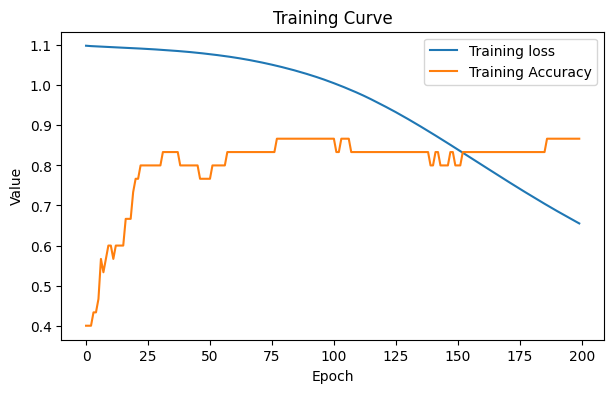

In [593]:
import matplotlib.pyplot as plt


plt.figure(figsize = (7,4))
plt.plot(history.history['loss'], label = "Training loss")
plt.plot(history.history['accuracy'], label = "Training Accuracy")
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


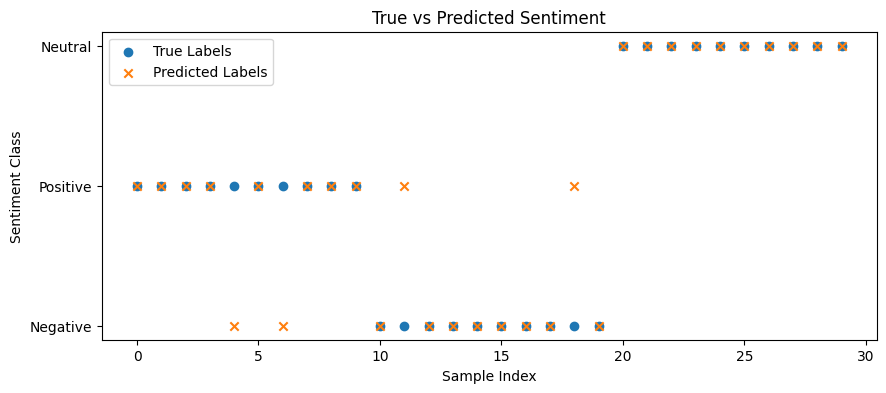

In [594]:
import matplotlib.pyplot as plt

raw_predictions = model.predict(X)
predicted_classes = np.argmax(raw_predictions, axis=1)

label_names = {0: "Negative", 1: "Positive", 2: "Neutral"}

plt.figure(figsize=(10, 4))
plt.scatter(range(len(labels)), labels, label="True Labels", marker="o")
plt.scatter(range(len(predicted_classes)), predicted_classes, label="Predicted Labels", marker="x")
plt.yticks([0, 1, 2], ["Negative", "Positive", "Neutral"])
plt.xlabel("Sample Index")
plt.ylabel("Sentiment Class")
plt.title("True vs Predicted Sentiment")
plt.legend()
plt.show()
